In [1]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tools import (
    simulate_data,
    bias_plot,
    estimate_s_learner,
    estimate_dml_aipw,
    simulations_sample_size,
    plot_aipw_decomposition
)
sns.set_theme(style="whitegrid", context="notebook")

In plain English, the underlying process that we are trying to estimate follows these rules.  
1. The treatment `D` (or the log-odds) has a linear relationship with the confunder matrix `X`.
2. Again, the treatment `D` has a linear relationship with the outcome determined by $\tau$.
3. The confounder matrix `X` affects the outcome `Y` nonlinearly.

Since `X` affects both `Y` and `D` when we observe changes on the treatment, we are going to observe changes on the confunders, and the resultant impact on the outcome would be both effects.


Formally
$$
\begin{array}{l}
X \sim \mathcal{N}(0,I) \\
D|X=x \sim Bernoulli(e(x)) \\
E[D|X=x] =  e(x) = logit^{-1}(x\top\beta) = \frac{1}{1+exp(-x\top\beta)} \\
Y|X = \tau D + g(x) + \epsilon \space \colon \space \ \epsilon_i \sim \mathcal{N}(0,1)
\end{array}
$$


We can take a sample of this population and observe how the standard estimation used for A/B tests $E[Y|D=1] - E[Y|D=0]$ is biased. 

In [8]:
# Sample from the data generation process

N=2000              # <- sample size 
P=30                # <- features involved
TAU = 1.5           # <- treatment effect
SEED = 123

X, D, Y = simulate_data(n=N, p=P, true_ate=TAU, seed=SEED)

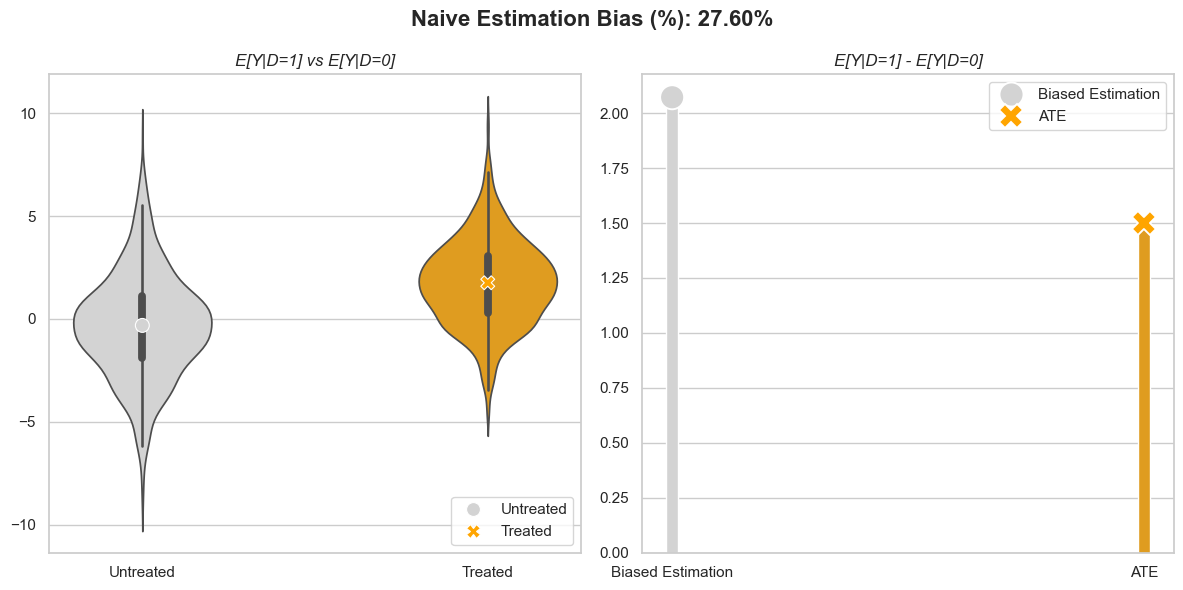

In [3]:
# visualice bias
bias_plot(Y=Y, D=D, X=X, ATE=TAU)

But this is not the most interesting biased estimation. The main value of the DML framework is not to improve this estimation method, but the estimations that one can naively try with a single machine learning model (S-Learner). S-Learners are biased due to regularization methods, that trade "variance" for "bias", to reduce overfiting problems. As a first approximation, let's estimate the treatment effect by fiting a model on Y, then estimate counterfactuals and compare with a DML method.

In [4]:
# Run simulations
SAMPLE_SIZES = [
    5_000,
    10_000,
    15_000,
    20_000,
    30_000,
]

# results_by_n = simulations_sample_size(
#     sample_sizes=SAMPLE_SIZES,
#     n_simulations=100,
#     p=50,
#     true_ate=TAU,
#     n_splits=5,
# )

# results_by_n.head()

In [5]:
# load_results
# results_by_n.to_csv("experiment_results.csv", index=False, sep=";")
results_by_n = pd.read_csv("experiment_results.csv", sep=";")

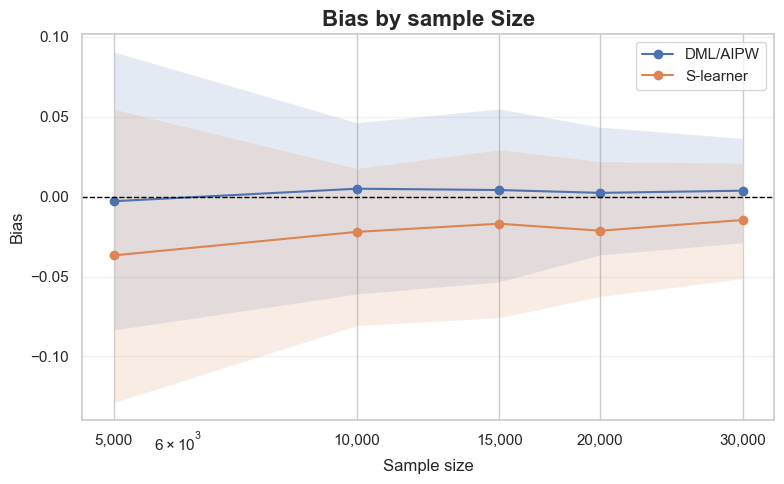

In [9]:
# Summarise simulation results
bias_summary = (
    results_by_n
    .groupby(["n", "Method"], as_index=False)
    .agg(
        median_bias=("Bias", "median"),
        lower_95=("Bias", lambda x: x.quantile(0.025)),
        upper_95=("Bias", lambda x: x.quantile(0.975)),
    )
)

fig, ax = plt.subplots(figsize=(8, 5))

for method, group in bias_summary.groupby("Method"):
    group = group.sort_values("n")

    ax.plot(
        group["n"],
        group["median_bias"],
        marker="o",
        linewidth=1.5,
        label=method,
    )

    ax.fill_between(
        group["n"],
        group["lower_95"],
        group["upper_95"],
        alpha=0.15,
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1)

ax.set(
    xscale="log",
    xlabel="Sample size",
    ylabel=r"Bias"
)
ax.set_title("Bias by sample Size", fontsize=16, fontweight='bold')

ax.set_xticks(SAMPLE_SIZES)
ax.set_xticklabels([f"{n:,}" for n in SAMPLE_SIZES])

ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

The result of the experiment allow us to observe at least 3 important things.
1. Using a standar predictive model to estimate causal effects can be biased.
2. This bias does not necessary converges to zero when as n incrases.
3. The confounding bias had a positive sign. The bias that we are observing here, is negative, so this is not caused by the confounding bias, but something else.
  
This can be understood trough the following fact; predictive models are trained to predict the outcomes that we observed at some point. Thus, the regularization amount is optimized for predictive purposes, but when you try to estimate what would've happend if we would've observed another value of `D` for a particular individual, regularization can be an obstacle

The next question is: how DML-APIW fix this problem? This is the process explained at high level.
1. Two models of the outcome are fitted, one with the control data $\hat\mu_0(x)$ and another with the treated $\hat\mu_1(x)$
2. Then we fit a model that estimates the propensity of beeing treated $\hat e(x)$
3. For each observation, we estimate the effect using the models that do not use the treatment $\hat\mu_1(x) - \hat\mu_0(x)$
4. Finally we have to give more credibility to the treated individuals, that have low propensity of beeing treated so give weight to the errors of the estimations.  
$$
\hat\mu_1(x) - \hat\mu_0(x) + D_i\frac{\hat\mu_1(x)-Y}{\hat e(X)} - (1-D_i)\frac{\hat\mu_0(x)-Y}{1-\hat e(X)}
$$

This final plot shows how the plug-in estimation (which is more robust than a S-Learner) is corrected using the residuals of the two outcome models. Starting from a biased estimation, the net effect of the correctios achieves to reduce the bias.

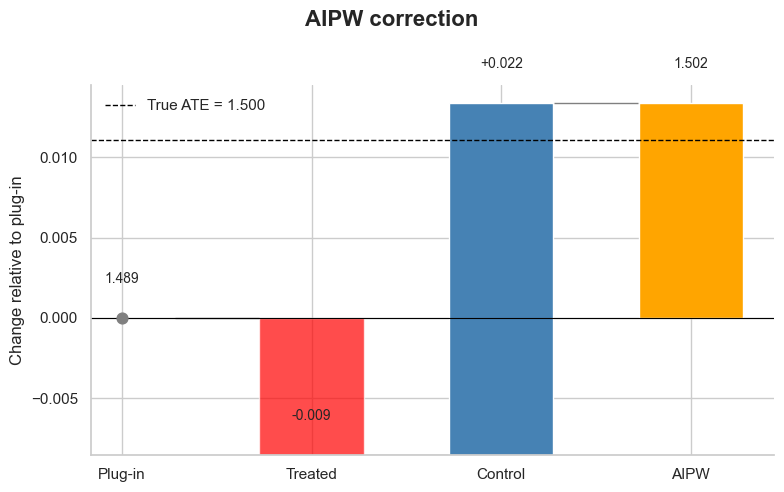

In [10]:
# Effect decomposition
X, D, Y = simulate_data(n=5000, p=30, true_ate=TAU, seed=SEED)
components_df = estimate_dml_aipw(X=X, Y=Y, D=D, n_splits=5, components=True, seed=SEED)
plot_aipw_decomposition(components_df.mean(), true_ate=TAU)